# Modo Batido

## Lectura de datos

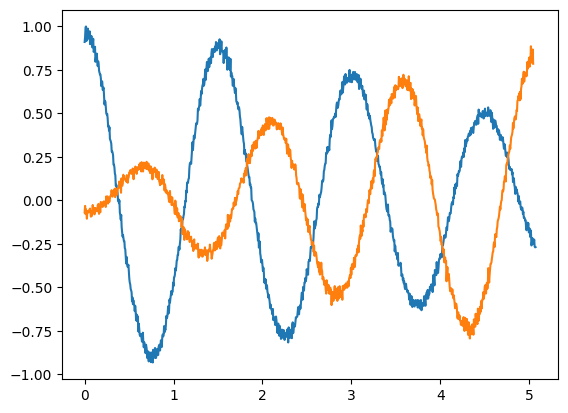

In [8]:
import numpy as np
import matplotlib.pyplot as plt

filas_iniciales_omitidas_1 = 28069 + 3130*2 + 104#mitad 1565 , entero 3130
filas_iniciales_omitidas_2 = 29757+ 1565 + 3130*2 + 104

filas_finales_omitidas_1 = 183000
filas_finales_omitidas_2 = 188000

filas_totales_1 = filas_finales_omitidas_1 - filas_iniciales_omitidas_1
filas_totales_2 = filas_finales_omitidas_2 - filas_iniciales_omitidas_2

data_1 = np.genfromtxt("Datos/MB_E1_CS.csv", delimiter=",", skip_header = filas_iniciales_omitidas_1, max_rows = filas_totales_1)
data_2 = np.genfromtxt("Datos/MB_E1_CF.csv", delimiter=",", skip_header = filas_iniciales_omitidas_2, max_rows = filas_totales_2)

tiempo_m1 = data_1[:,0] - data_1[0,0] 
aceleracion_y_1_aux = data_1[:,2] 
#División de datos para el valor máximo
aceleracion_y_1 = aceleracion_y_1_aux/np.max(aceleracion_y_1_aux)

tiempo_2 = data_2[:,0] - data_2[0,0]
aceleracion_y_2_aux = data_2[:,2]
#División de datos para el valor máximo
aceleracion_y_2 = aceleracion_y_2_aux/np.max(aceleracion_y_2_aux)

fft_resultados_1 = np.fft.fft(aceleracion_y_1)
d_1 = (tiempo_m1[-1] - tiempo_m1[0])/len(tiempo_m1) #Cuánto tiempo avanza por dato celular 1 [s/#dato]
frecuencias_1_m1 = np.fft.fftfreq(len(aceleracion_y_1), d_1)

fft_resultados_2 = np.fft.fft(aceleracion_y_2)
d_2 = (tiempo_2[-1] - tiempo_2[0])/len(tiempo_2) #Cuánto tiempo avanza por dato celular 2 [s/#dato]
frecuencias_2 = np.fft.fftfreq(len(aceleracion_y_2), d_2)


plt.plot(tiempo_m1[:1000],aceleracion_y_1[:1000])
plt.plot(tiempo_2[:1000],aceleracion_y_2[:1000])


## Hallar máximos FFT

In [9]:
#Primer Celular

Transformada_1 = np.abs(fft_resultados_1[:500])
Transformada_2 = np.abs(fft_resultados_1[500:len(frecuencias_1_m1)//2])
frecuencias_1_m1_aux = frecuencias_1_m1[500:len(frecuencias_1_m1)//2]
# Frecuencia primer pico
posicion_maximo_1 = np.where(Transformada_1 == np.max(Transformada_1))
frecuencia_maximo_1 = frecuencias_1_m1[posicion_maximo_1[0]]
print('Primer Celular')
#print('Primer pico:', 'v1: ',frecuencia_maximo_1[0], '[Hz]')
print('Primer pico:', 'w1: ',frecuencia_maximo_1[0]*(2* np.pi), '[rad/s]')

# Frecuencia segundo pico
posicion_maximo_2 = np.where(Transformada_2 == np.max(Transformada_2))
frecuencia_maximo_2 = frecuencias_1_m1_aux[posicion_maximo_2[0]]
#print('Segundo pico:', 'v2: ',frecuencia_maximo_2[0], '[Hz]')
print('Segundo pico:', 'w2: ',frecuencia_maximo_2[0]*(2* np.pi), '[rad/s]')

# Guardar datos celular 1
frecuencia_pico_1_celular_1 = frecuencia_maximo_1[0]*(2* np.pi)
frecuencia_pico_2_celular_1 = frecuencia_maximo_2[0]*(2* np.pi)

print('')
#Segundo Celular

Transformada_1 = np.abs(fft_resultados_2[:500])
Transformada_2 = np.abs(fft_resultados_2[500:len(frecuencias_2)//2])
frecuencias_2_aux = frecuencias_2[500:len(frecuencias_2)//2]
# Frecuencia primer pico
posicion_maximo_1 = np.where(Transformada_1 == np.max(Transformada_1))
frecuencia_maximo_1 = frecuencias_2[posicion_maximo_1[0]]
print('Segundo Celular')
#print('Primer pico:', 'v1: ',frecuencia_maximo_1[0], '[Hz]')
print('Primer pico:', 'w1: ',frecuencia_maximo_1[0]*(2* np.pi), '[rad/s]')

# Frecuencia segundo pico
posicion_maximo_2 = np.where(Transformada_2 == np.max(Transformada_2))
frecuencia_maximo_2 = frecuencias_2_aux[posicion_maximo_2[0]]
#print('Segundo pico:', 'v2: ',frecuencia_maximo_2[0], '[Hz]')
print('Segundo pico:', 'w2: ',frecuencia_maximo_2[0]*(2* np.pi), '[rad/s]')

# Guardar datos celular 2
frecuencia_pico_1_celular_2 = frecuencia_maximo_1[0]*(2* np.pi)
frecuencia_pico_2_celular_2 = frecuencia_maximo_2[0]*(2* np.pi)

Primer Celular
Primer pico: w1:  3.9986599891577352 [rad/s]
Segundo pico: w2:  4.4068565297175875 [rad/s]

Segundo Celular
Primer pico: w1:  3.9980588843547045 [rad/s]
Segundo pico: w2:  4.40365906102837 [rad/s]


## Regresión exponencial

C:\Users\Sebas\AppData\Local\Temp\ipykernel_17204\1087825506.py:51: RuntimeWarning: overflow encountered in exp
  return c*np.exp(-d* x) + e*np.exp(-f*x)


(0.0, 150.0)

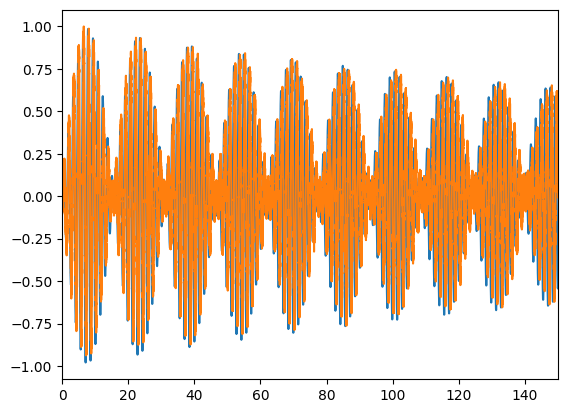

In [10]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

## Fit exponencial

d_1 = (tiempo_m1[-1] - tiempo_m1[0])/len(tiempo_m1) #Intervalo de tiempo por número de puntos
d_2 = (tiempo_2[-1] - tiempo_2[0])/len(tiempo_2)
w1_c1 = (frecuencia_pico_2_celular_1 - frecuencia_pico_1_celular_1)/2
w1_c2 = (frecuencia_pico_2_celular_2 - frecuencia_pico_1_celular_2)/2
T1 = (2*np.pi/(w1_c1))/(d_1) # Periodo en número de puntos
T2 = (2*np.pi/(w1_c2))/(d_2)
numero_batidos_c1 = int(len(tiempo_m1)/(T1/2))
numero_batidos_c2 = int(len(tiempo_2)/(T2/2))

aceleraciones_maximo_c1 = []
tiempos_maximo_c1= []
aceleraciones_maximo_c2 = []
tiempos_maximo_c2= []

for i in range(numero_batidos_c1):
    # Divido cada batido en un array
    tiempo_m1_aux = tiempo_m1[i*int(T1/2):(i+1)*int(T1/2)]
    aceleracion_y_1_aux = aceleracion_y_1[i*int(T1/2):(i+1)*int(T1/2)]

    # Hallo la posición del máximo de cada batido
    posicion_maximo_aceleracion = np.argmax(aceleracion_y_1_aux)
    #Formo los vectores tiempo y aceleración maximos
    aceleraciones_maximo_c1.append(aceleracion_y_1_aux[posicion_maximo_aceleracion])
    tiempos_maximo_c1.append(tiempo_m1_aux[posicion_maximo_aceleracion])

tiempos_maximo_c1[0] = 0

for i in range(numero_batidos_c2):
    # Divido cada batido en un array
    tiempo_m1_aux = tiempo_2[i*int(T2/2):(i+1)*int(T2/2)]
    aceleracion_y_1_aux = aceleracion_y_2[i*int(T2/2):(i+1)*int(T2/2)]

    # Hallo la posición del máximo de cada batido
    posicion_maximo_aceleracion = np.argmax(aceleracion_y_1_aux)
    #Formo los vectores tiempo y aceleración maximos
    aceleraciones_maximo_c2.append(aceleracion_y_1_aux[posicion_maximo_aceleracion])
    tiempos_maximo_c2.append(tiempo_m1_aux[posicion_maximo_aceleracion])

# Para verificar que todo está bien:
#plt.plot(tiempos_maximo_c2[:], aceleraciones_maximo_c2[:])
#plt.plot(tiempo_2[:], aceleracion_y_2[:])

## Definimos el ajuste exponencial
def modelo1(x, c, d, e, f):
    return c*np.exp(-d* x) + e*np.exp(-f*x)


## Realizamos el ajuste exponencial:
params_1, errr = curve_fit(modelo1, tiempos_maximo_c1[:], aceleraciones_maximo_c1[:])
params_2, errr_2 = curve_fit(modelo1, tiempos_maximo_c2[:], aceleraciones_maximo_c2[:])

## Creamos la curva exponencial:
x_continuo = np.linspace(min(tiempos_maximo_c2[:]), max(tiempos_maximo_c2[:]), 100)
y_fit_continuo_exponencial = modelo1(x_continuo, *params_2)

## Graficamos la regresión exponencial:
#plt.scatter(tiempos_maximo[:], aceleraciones_maximo[:], label='Datos', color='blue')
#plt.plot(x_continuo, y_fit_continuo_exponencial, label='Ajuste exponencial', color='orange')
#plt.xlabel('tiempo')
#plt.ylabel('a_max_y')
#plt.legend()
#plt.show()

#Valores hallados:
c_1 = params_1[0]
d_1 = params_1[1]
e_1 = params_1[2]
f_1 = params_1[3]

c_2 = params_2[0]
d_2 = params_2[1]
e_2 = params_2[2]
f_2 = params_2[3]

wa_c1 = frecuencia_pico_2_celular_1
ws_c1 = frecuencia_pico_1_celular_1

wa_c2 = frecuencia_pico_2_celular_2
ws_c2 = frecuencia_pico_1_celular_2

graf_aceleracion_c1 = (ws_c1*ws_c1*np.cos(ws_c1*tiempo_m1) + wa_c1*wa_c1*np.cos(wa_c1*tiempo_m1))*(c_1*np.exp(-d_1* tiempo_m1) + e_1*np.exp(-f_1*tiempo_m1))/(ws_c1**2+wa_c1**2)
graf_aceleracion_c2 = (ws_c2*ws_c2*np.cos(ws_c2*tiempo_2) - wa_c2*wa_c2*np.cos(wa_c2*tiempo_2))*(c_2*np.exp(-d_2* tiempo_2) + e_2*np.exp(-f_2*tiempo_2))/(ws_c2**2+wa_c2**2)

## Para verificar la 
plt.plot(tiempo_2[:],graf_aceleracion_c2[:])
plt.plot(tiempo_2[:],aceleracion_y_2[:])
plt.xlim(0, 150)

## Graficar

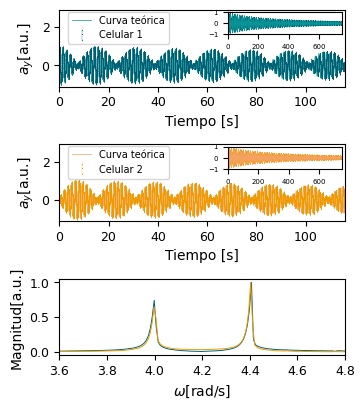

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#plt.figure(figsize=(12, 12))
plt.figure(figsize=(3.75, 4.2))

error_y = np.full(len(tiempo_m1), 0.04)

ax1 = plt.subplot(3, 1, 1)
#plt.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt='.', color='#005F73', capsize=0.3, label='Celular 1', markersize=0.1, elinewidth=0.5)
plt.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt=',', color='#005F73', capsize=0.3, label='Celular 1', elinewidth=0.2)
#plt.plot(tiempo_m1, aceleracion_y_1, color='#005F73', label='Celular 1', linewidth=0.5)
plt.plot(tiempo_m1[:],graf_aceleracion_c1[:], label='Curva teórica', linewidth=0.5, color='#0A9396')
plt.legend(loc='lower right', bbox_to_anchor=(0.4, 0.49), fontsize=7)
plt.xlabel('Tiempo [s]', fontsize=10)
plt.ylabel(r"$a_y$[a.u.]", fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(0, 116)
plt.ylim(-1.1, 2.9)
# Agregar el inset en el primer gráfico
inset_ax = ax1.inset_axes([0.59, 0.68, 0.40, 0.29])  # [x0, y0, ancho, alto] en fracciones del gráfico principal
#inset_ax.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt=',', color='#005F73', capsize=0.1, elinewidth=0.2)
inset_ax.plot(tiempo_m1, aceleracion_y_1, color='#005F73', linewidth=0.3)
inset_ax.plot(tiempo_m1[:],graf_aceleracion_c1[:], linewidth=0.1, color='#0A9396')
inset_ax.tick_params(labelsize=5)
inset_ax.set_xlim(0, 750)  # Ajusta los límites para hacer zoom
inset_ax.set_ylim(-1, 1)

error_y = np.full(len(tiempo_2), 0.04)

ax2 = plt.subplot(3, 1, 2)
plt.errorbar(tiempo_2, aceleracion_y_2, yerr=error_y, fmt=',', color='#EE9B00', capsize=0.3, label='Celular 2', elinewidth=0.2)
#plt.plot(tiempo_2, aceleracion_y_2, color='#EE9B00', label='Celular 2', linewidth=0.5)
plt.plot(tiempo_2[:],graf_aceleracion_c2[:], label='Curva teórica', linewidth=0.5, color='#F4A261')
plt.legend(loc='lower right', bbox_to_anchor=(0.4, 0.49), fontsize=7)
plt.xlabel('Tiempo [s]', fontsize=10)
plt.ylabel(r"$a_y$[a.u.]", fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(0, 116)
plt.ylim(-1.1, 2.9)
# Agregar el inset en elsegundo gráfico
inset_ax = ax2.inset_axes([0.59, 0.68, 0.40, 0.29])  # [x0, y0, ancho, alto] en fracciones del gráfico principal
#inset_ax.errorbar(tiempo_2, aceleracion_y_2, yerr=error_y, fmt=',', color='#EE9B00', capsize=1)
inset_ax.plot(tiempo_2, aceleracion_y_2, color='#EE9B00', linewidth=0.3)
inset_ax.plot(tiempo_2[:],graf_aceleracion_c2[:], linewidth=0.1, color='#F4A261')
inset_ax.tick_params(labelsize=5)
inset_ax.set_xlim(0, 750)  # Ajusta los límites para hacer zoom
inset_ax.set_ylim(-1, 1)

ax3 = plt.subplot(3, 1, 3)

frecuencia_maximo_grafica_1 = len(frecuencias_1_m1)//2 # Hasta 800 para primer pico
frecuencia_maximo_grafica_2 = len(frecuencias_2)//2
auxiliar_normalizar = np.abs(fft_resultados_1)[:len(fft_resultados_1)//2]/np.max(np.abs(fft_resultados_1)[:len(fft_resultados_1)//2])
plt.plot(frecuencias_1_m1[:len(fft_resultados_1)//2]*(2* np.pi), auxiliar_normalizar, color='#005F73', linewidth=0.7)  # Solo la mitad positiva
auxiliar_normalizar = np.abs(fft_resultados_2)[:len(fft_resultados_2)//2]/np.max(np.abs(fft_resultados_2)[:len(fft_resultados_2)//2])
plt.plot(frecuencias_2[:len(fft_resultados_2)//2]*(2* np.pi), auxiliar_normalizar, color='#EE9B00', linewidth=0.7)  
#plt.title('Transformada Rápida de Fourier')
plt.xlabel(r"$\omega$[rad/s]", fontsize=10)
plt.ylabel('Magnitud[a.u.]', fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(3.6,4.8)

plt.tight_layout()

plt.savefig("modo_batido.png", dpi=300, bbox_inches='tight')

plt.show()


In [12]:
import numpy as np
auxiliar_normalizar = np.abs(fft_resultados_1)[:len(fft_resultados_1)//2]/np.max(np.abs(fft_resultados_1)[:len(fft_resultados_1)//2])
data_exportar_transformada_Fourier_1 = np.column_stack((frecuencias_1_m1[:len(fft_resultados_1)//2]*(2* np.pi), auxiliar_normalizar))
np.savetxt("MB_FFT_C1.csv", data_exportar_transformada_Fourier_1, delimiter=",", header="Frecuencia, Magnitud", comments="")

auxiliar_normalizar = np.abs(fft_resultados_2)[:len(fft_resultados_2)//2]/np.max(np.abs(fft_resultados_2)[:len(fft_resultados_2)//2])
data_exportar_transformada_Fourier_2 = np.column_stack((frecuencias_2[:len(fft_resultados_2)//2]*(2* np.pi), auxiliar_normalizar))
np.savetxt("MB_FFT_C2.csv", data_exportar_transformada_Fourier_2, delimiter=",", header="Frecuencia, Magnitud", comments="")



# Modo Simétrico

## Lectura de datos

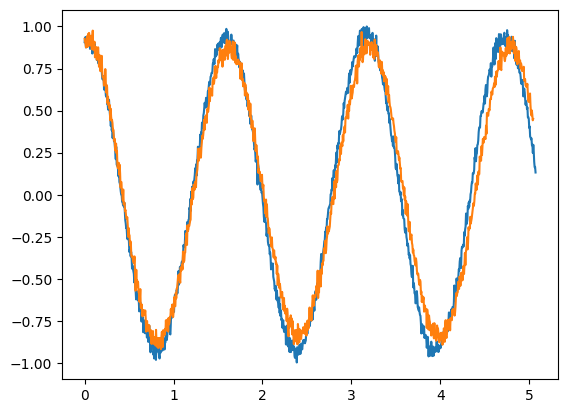

In [13]:
import numpy as np
import matplotlib.pyplot as plt

filas_iniciales_omitidas_1 = 13398 + 3*312 + 100 #13398
filas_iniciales_omitidas_2 = 13450 + 3*312 + 100 #13450 un ciclo 312

filas_finales_omitidas_1 = 128500
filas_finales_omitidas_2 = 129000

filas_totales_1 = filas_finales_omitidas_1 - filas_iniciales_omitidas_1
filas_totales_2 = filas_finales_omitidas_2 - filas_iniciales_omitidas_2

data_1 = np.genfromtxt("Datos/MS_E2_CS.csv", delimiter=",", skip_header = filas_iniciales_omitidas_1, max_rows = filas_totales_1)
data_2 = np.genfromtxt("Datos/MS_E2_CF.csv", delimiter=",", skip_header = filas_iniciales_omitidas_2, max_rows = filas_totales_2)

tiempo_m1 = data_1[:,0] - data_1[0,0] 
aceleracion_y_1_aux = data_1[:,2] 
#División de datos para el valor máximo
aceleracion_y_1 = aceleracion_y_1_aux/np.max(aceleracion_y_1_aux)

tiempo_2 = data_2[:,0] - data_2[0,0]
aceleracion_y_2_aux = data_2[:,2]
#División de datos para el valor máximo
aceleracion_y_2 = aceleracion_y_2_aux/np.max(aceleracion_y_2_aux)

fft_resultados_1 = np.fft.fft(aceleracion_y_1)
d_1 = (tiempo_m1[-1] - tiempo_m1[0])/len(tiempo_m1) #Cuánto tiempo avanza por dato celular 1 [s/#dato]
frecuencias_1_m1 = np.fft.fftfreq(len(aceleracion_y_1), d_1)

fft_resultados_2 = np.fft.fft(aceleracion_y_2)
d_2 = (tiempo_2[-1] - tiempo_2[0])/len(tiempo_2) #Cuánto tiempo avanza por dato celular 2 [s/#dato]
frecuencias_2 = np.fft.fftfreq(len(aceleracion_y_2), d_2)


plt.plot(tiempo_m1[:1000],aceleracion_y_1[:1000])
plt.plot(tiempo_2[:1000],aceleracion_y_2[:1000])


## Hallar máximos FFT

In [14]:
#Primer Celular

Transformada_1 = np.abs(fft_resultados_1[:500])
Transformada_2 = np.abs(fft_resultados_1[500:len(frecuencias_1_m1)//2])
frecuencias_1_m1_aux = frecuencias_1_m1[500:len(frecuencias_1_m1)//2]
# Frecuencia primer pico
posicion_maximo_1 = np.where(Transformada_1 == np.max(Transformada_1))
frecuencia_maximo_1 = frecuencias_1_m1[posicion_maximo_1[0]]
print('Primer Celular')
#print('Primer pico:', 'v1: ',frecuencia_maximo_1[0], '[Hz]')
print('Primer pico:', 'w1: ',frecuencia_maximo_1[0]*(2* np.pi), '[rad/s]')

# Frecuencia segundo pico
posicion_maximo_2 = np.where(Transformada_2 == np.max(Transformada_2))
frecuencia_maximo_2 = frecuencias_1_m1_aux[posicion_maximo_2[0]]
#print('Segundo pico:', 'v2: ',frecuencia_maximo_2[0], '[Hz]')
print('Segundo pico:', 'w2: ',frecuencia_maximo_2[0]*(2* np.pi), '[rad/s]')

# Guardar datos celular 1
frecuencia_pico_1_celular_1 = frecuencia_maximo_1[0]*(2* np.pi)
frecuencia_pico_2_celular_1 = frecuencia_maximo_2[0]*(2* np.pi)

print('')
#Segundo Celular

Transformada_1 = np.abs(fft_resultados_2[:500])
Transformada_2 = np.abs(fft_resultados_2[500:len(frecuencias_2)//2])
frecuencias_2_aux = frecuencias_2[500:len(frecuencias_2)//2]
# Frecuencia primer pico
posicion_maximo_1 = np.where(Transformada_1 == np.max(Transformada_1))
frecuencia_maximo_1 = frecuencias_2[posicion_maximo_1[0]]
print('Segundo Celular')
#print('Primer pico:', 'v1: ',frecuencia_maximo_1[0], '[Hz]')
print('Primer pico:', 'w1: ',frecuencia_maximo_1[0]*(2* np.pi), '[rad/s]')

# Frecuencia segundo pico
posicion_maximo_2 = np.where(Transformada_2 == np.max(Transformada_2))
frecuencia_maximo_2 = frecuencias_2_aux[posicion_maximo_2[0]]
#print('Segundo pico:', 'v2: ',frecuencia_maximo_2[0], '[Hz]')
print('Segundo pico:', 'w2: ',frecuencia_maximo_2[0]*(2* np.pi), '[rad/s]')

# Guardar datos celular 2
frecuencia_pico_1_celular_2 = frecuencia_maximo_1[0]*(2* np.pi)
frecuencia_pico_2_celular_2 = frecuencia_maximo_2[0]*(2* np.pi)

Primer Celular
Primer pico: w1:  4.0038108585497625 [rad/s]
Segundo pico: w2:  305.418070586609 [rad/s]

Segundo Celular
Primer pico: w1:  4.009308885757956 [rad/s]
Segundo pico: w2:  307.0543878360971 [rad/s]


## Regresión exponencial

C:\Users\Sebas\AppData\Local\Temp\ipykernel_17204\4254958831.py:51: RuntimeWarning: overflow encountered in exp
  return c*np.exp(-d* x) + e*np.exp(-f*x)


(0.0, 10.0)

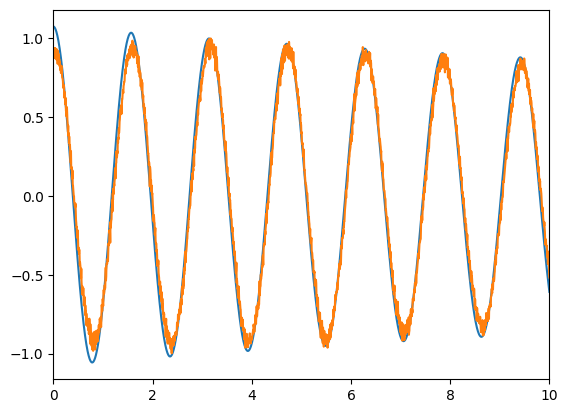

In [15]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

## Fit exponencial

d_1 = (tiempo_m1[-1] - tiempo_m1[0])/len(tiempo_m1) #Intervalo de tiempo por número de puntos
d_2 = (tiempo_2[-1] - tiempo_2[0])/len(tiempo_2)
w1_c1 = frecuencia_pico_1_celular_1
w1_c2 = frecuencia_pico_1_celular_2
T1 = (2*np.pi/(w1_c1))/(d_1) # Periodo en número de puntos
T2 = (2*np.pi/(w1_c2))/(d_2)
numero_batidos_c1 = int(len(tiempo_m1)/(T1/2))
numero_batidos_c2 = int(len(tiempo_2)/(T2/2))

aceleraciones_maximo_c1 = []
tiempos_maximo_c1= []
aceleraciones_maximo_c2 = []
tiempos_maximo_c2= []

for i in range(numero_batidos_c1):
    # Divido cada batido en un array
    tiempo_m1_aux = tiempo_m1[i*int(T1/2):(i+1)*int(T1/2)]
    aceleracion_y_1_aux = aceleracion_y_1[i*int(T1/2):(i+1)*int(T1/2)]

    # Hallo la posición del máximo de cada batido
    posicion_maximo_aceleracion = np.argmax(aceleracion_y_1_aux)
    #Formo los vectores tiempo y aceleración maximos
    aceleraciones_maximo_c1.append(aceleracion_y_1_aux[posicion_maximo_aceleracion])
    tiempos_maximo_c1.append(tiempo_m1_aux[posicion_maximo_aceleracion])

tiempos_maximo_c1[0] = 0

for i in range(numero_batidos_c2):
    # Divido cada batido en un array
    tiempo_m1_aux = tiempo_2[i*int(T2/2):(i+1)*int(T2/2)]
    aceleracion_y_1_aux = aceleracion_y_2[i*int(T2/2):(i+1)*int(T2/2)]

    # Hallo la posición del máximo de cada batido
    posicion_maximo_aceleracion = np.argmax(aceleracion_y_1_aux)
    #Formo los vectores tiempo y aceleración maximos
    aceleraciones_maximo_c2.append(aceleracion_y_1_aux[posicion_maximo_aceleracion])
    tiempos_maximo_c2.append(tiempo_m1_aux[posicion_maximo_aceleracion])

# Para verificar que todo está bien:
#plt.plot(tiempos_maximo_c2[:], aceleraciones_maximo_c2[:])
#plt.plot(tiempo_2[:], aceleracion_y_2[:])

## Definimos el ajuste exponencial
def modelo1(x, c, d, e, f):
    return c*np.exp(-d* x) + e*np.exp(-f*x)


## Realizamos el ajuste exponencial:
params_1, errr = curve_fit(modelo1, tiempos_maximo_c1[:], aceleraciones_maximo_c1[:])
params_2, errr_2 = curve_fit(modelo1, tiempos_maximo_c2[:], aceleraciones_maximo_c2[:])

## Creamos la curva exponencial:
x_continuo = np.linspace(min(tiempos_maximo_c2[:]), max(tiempos_maximo_c2[:]), 100)
y_fit_continuo_exponencial = modelo1(x_continuo, *params_2)

## Graficamos la regresión exponencial:
#plt.scatter(tiempos_maximo[:], aceleraciones_maximo[:], label='Datos', color='blue')
#plt.plot(x_continuo, y_fit_continuo_exponencial, label='Ajuste exponencial', color='orange')
#plt.xlabel('tiempo')
#plt.ylabel('a_max_y')
#plt.legend()
#plt.show()

#Valores hallados:
c_1 = params_1[0]
d_1 = params_1[1]
e_1 = params_1[2]
f_1 = params_1[3]

c_2 = params_2[0]
d_2 = params_2[1]
e_2 = params_2[2]
f_2 = params_2[3]

wa_c1 = frecuencia_pico_2_celular_1
ws_c1 = frecuencia_pico_1_celular_1

wa_c2 = frecuencia_pico_2_celular_2
ws_c2 = frecuencia_pico_1_celular_2

graf_aceleracion_c1 = (ws_c1*ws_c1*np.cos(ws_c1*tiempo_m1) )*(c_1*np.exp(-d_1* tiempo_m1) + e_1*np.exp(-f_1*tiempo_m1))/(ws_c1**2)
graf_aceleracion_c2 = (ws_c2*ws_c2*np.cos(ws_c2*tiempo_2) )*(c_2*np.exp(-d_2* tiempo_2) + e_2*np.exp(-f_2*tiempo_2))/(ws_c2**2)

## Para verificar la 
plt.plot(tiempo_m1[:],graf_aceleracion_c1[:])
plt.plot(tiempo_m1[:],aceleracion_y_1[:])
plt.xlim(0, 10)

## Graficar

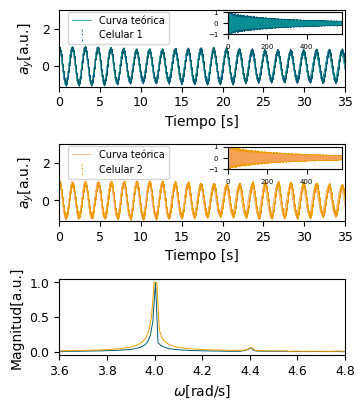

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(3.75, 4.2))

error_y = np.full(len(tiempo_m1), 0.04)

ax1 = plt.subplot(3, 1, 1)
#plt.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt='.', color='#005F73', capsize=0.3, label='Celular 1', markersize=0.1, elinewidth=0.5)
plt.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt=',', color='#005F73', capsize=0.3, label='Celular 1', elinewidth=0.2)
#plt.plot(tiempo_m1, aceleracion_y_1, color='#005F73', label='Celular 1', linewidth=0.5)
plt.plot(tiempo_m1[:],graf_aceleracion_c1[:], label='Curva teórica', linewidth=0.5, color='#0A9396')
plt.legend(loc='lower right', bbox_to_anchor=(0.4, 0.49), fontsize=7)
plt.xlabel('Tiempo [s]', fontsize=10)
plt.ylabel(r"$a_y$[a.u.]", fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(0, 35)
plt.ylim(-1.1, 3.)
# Agregar el inset en el primer gráfico
inset_ax = ax1.inset_axes([0.59, 0.68, 0.40, 0.29])  # [x0, y0, ancho, alto] en fracciones del gráfico principal
#inset_ax.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt=',', color='#005F73', capsize=0.1, elinewidth=0.2)
inset_ax.plot(tiempo_m1, aceleracion_y_1, color='#005F73', linewidth=0.3)
inset_ax.plot(tiempo_m1[:],graf_aceleracion_c1[:], linewidth=0.1, color='#0A9396')
inset_ax.tick_params(labelsize=5)
inset_ax.set_xlim(0, 580)  # Ajusta los límites para hacer zoom
inset_ax.set_ylim(-1, 1)

error_y = np.full(len(tiempo_2), 0.04)

ax2 = plt.subplot(3, 1, 2)
plt.errorbar(tiempo_2, aceleracion_y_2, yerr=error_y, fmt=',', color='#EE9B00', capsize=0.3, label='Celular 2', elinewidth=0.2)
#plt.plot(tiempo_2, aceleracion_y_2, color='#EE9B00', label='Celular 2', linewidth=0.5)
plt.plot(tiempo_2[:],graf_aceleracion_c2[:], label='Curva teórica', linewidth=0.5, color='#F4A261')
plt.legend(loc='lower right', bbox_to_anchor=(0.4, 0.49), fontsize=7)
plt.xlabel('Tiempo [s]', fontsize=10)
plt.ylabel(r"$a_y$[a.u.]", fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(0, 35)
plt.ylim(-1.1, 3.)
# Agregar el inset en elsegundo gráfico
inset_ax = ax2.inset_axes([0.59, 0.68, 0.40, 0.29])  # [x0, y0, ancho, alto] en fracciones del gráfico principal
#inset_ax.errorbar(tiempo_2, aceleracion_y_2, yerr=error_y, fmt=',', color='#EE9B00', capsize=1)
inset_ax.plot(tiempo_2, aceleracion_y_2, color='#EE9B00', linewidth=0.3)
inset_ax.plot(tiempo_2[:],graf_aceleracion_c2[:], linewidth=0.1, color='#F4A261')
inset_ax.tick_params(labelsize=5)
inset_ax.set_xlim(0, 580)  # Ajusta los límites para hacer zoom
inset_ax.set_ylim(-1, 1)

ax3 = plt.subplot(3, 1, 3)

frecuencia_maximo_grafica_1 = len(frecuencias_1_m1)//2 # Hasta 800 para primer pico
frecuencia_maximo_grafica_2 = len(frecuencias_2)//2
auxiliar_normalizar = np.abs(fft_resultados_1)[:len(fft_resultados_1)//2]/np.max(np.abs(fft_resultados_1)[:len(fft_resultados_1)//2])
plt.plot(frecuencias_1_m1[:len(frecuencias_1_m1)//2]*(2* np.pi), auxiliar_normalizar, color='#005F73', linewidth=0.7)  # Solo la mitad positiva
auxiliar_normalizar = np.abs(fft_resultados_2)[:len(fft_resultados_2)//2]/np.max(np.abs(fft_resultados_2)[:len(fft_resultados_2)//2])
plt.plot(frecuencias_2[:len(fft_resultados_2)//2]*(2* np.pi), auxiliar_normalizar, color='#EE9B00', linewidth=0.7)  
#plt.title('Transformada Rápida de Fourier')
plt.xlabel(r"$\omega$[rad/s]", fontsize=10)
plt.ylabel('Magnitud[a.u.]', fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(3.6,4.8)

plt.tight_layout()

plt.savefig("modo_simetrico.png", dpi=300, bbox_inches='tight')

plt.show()

In [17]:
import numpy as np
auxiliar_normalizar = np.abs(fft_resultados_1)[:len(fft_resultados_1)//2]/np.max(np.abs(fft_resultados_1)[:len(fft_resultados_1)//2])
data_exportar_transformada_Fourier_1 = np.column_stack((frecuencias_1_m1[:len(fft_resultados_1)//2]*(2* np.pi), auxiliar_normalizar))
np.savetxt("MS_FFT_C1.csv", data_exportar_transformada_Fourier_1, delimiter=",", header="Frecuencia, Magnitud", comments="")

auxiliar_normalizar = np.abs(fft_resultados_2)[:len(fft_resultados_2)//2]/np.max(np.abs(fft_resultados_2)[:len(fft_resultados_2)//2])
data_exportar_transformada_Fourier_2 = np.column_stack((frecuencias_2[:len(fft_resultados_2)//2]*(2* np.pi), auxiliar_normalizar))
np.savetxt("MS_FFT_C2.csv", data_exportar_transformada_Fourier_2, delimiter=",", header="Frecuencia, Magnitud", comments="")


# Modo Antisimétrico

## Lectura de datos

<>:13: SyntaxWarning: invalid escape sequence '\M'
<>:14: SyntaxWarning: invalid escape sequence '\M'
<>:13: SyntaxWarning: invalid escape sequence '\M'
<>:14: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Sebas\AppData\Local\Temp\ipykernel_17204\334666201.py:13: SyntaxWarning: invalid escape sequence '\M'
  data_1 = np.genfromtxt("Datos\MA_E2_CS.csv", delimiter=",", skip_header = filas_iniciales_omitidas_1, max_rows = filas_totales_1)
C:\Users\Sebas\AppData\Local\Temp\ipykernel_17204\334666201.py:14: SyntaxWarning: invalid escape sequence '\M'
  data_2 = np.genfromtxt("Datos\MA_E2_CF.csv", delimiter=",", skip_header = filas_iniciales_omitidas_2, max_rows = filas_totales_2)


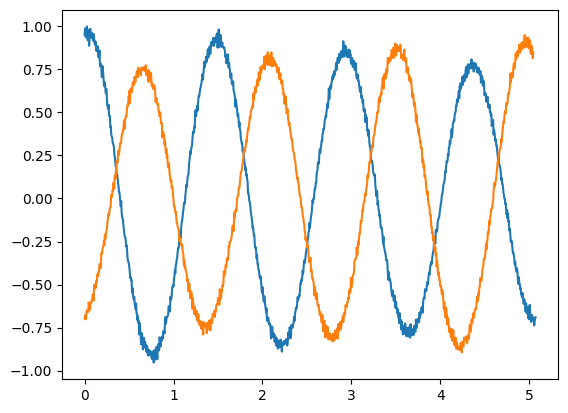

In [18]:
import numpy as np
import matplotlib.pyplot as plt

filas_iniciales_omitidas_1 = 28739 #25804 + 2757 + 178
filas_iniciales_omitidas_2 = 28891#25941 + 2772 + 178

filas_finales_omitidas_1 = 203087
filas_finales_omitidas_2 = 204163

filas_totales_1 = filas_finales_omitidas_1 - filas_iniciales_omitidas_1
filas_totales_2 = filas_finales_omitidas_2 - filas_iniciales_omitidas_2

data_1 = np.genfromtxt("Datos\MA_E2_CS.csv", delimiter=",", skip_header = filas_iniciales_omitidas_1, max_rows = filas_totales_1)
data_2 = np.genfromtxt("Datos\MA_E2_CF.csv", delimiter=",", skip_header = filas_iniciales_omitidas_2, max_rows = filas_totales_2)

tiempo_m1 = data_1[:,0] - data_1[0,0] 
aceleracion_y_1_aux = data_1[:,2] 
#División de datos para el valor máximo
aceleracion_y_1 = aceleracion_y_1_aux/np.max(aceleracion_y_1_aux)

tiempo_2 = data_2[:,0] - data_2[0,0]
aceleracion_y_2_aux = data_2[:,2]
#División de datos para el valor máximo
aceleracion_y_2 = aceleracion_y_2_aux/np.max(aceleracion_y_2_aux)

fft_resultados_1 = np.fft.fft(aceleracion_y_1)
d_1 = (tiempo_m1[-1] - tiempo_m1[0])/len(tiempo_m1) #Cuánto tiempo avanza por dato celular 1 [s/#dato]
frecuencias_1_m1 = np.fft.fftfreq(len(aceleracion_y_1), d_1)

fft_resultados_2 = np.fft.fft(aceleracion_y_2)
d_2 = (tiempo_2[-1] - tiempo_2[0])/len(tiempo_2) #Cuánto tiempo avanza por dato celular 2 [s/#dato]
frecuencias_2 = np.fft.fftfreq(len(aceleracion_y_2), d_2)


plt.plot(tiempo_m1[:1000],aceleracion_y_1[:1000])
plt.plot(tiempo_2[:1000],aceleracion_y_2[:1000])


## Hallar máximos FFT

In [19]:
#Primer Celular

Transformada_1 = np.abs(fft_resultados_1[:500])
Transformada_2 = np.abs(fft_resultados_1[500:len(frecuencias_1_m1)//2])
frecuencias_1_m1_aux = frecuencias_1_m1[500:len(frecuencias_1_m1)//2]
# Frecuencia primer pico
posicion_maximo_1 = np.where(Transformada_1 == np.max(Transformada_1))
frecuencia_maximo_1 = frecuencias_1_m1[posicion_maximo_1[0]]
print('Primer Celular')
#print('Primer pico:', 'v1: ',frecuencia_maximo_1[0], '[Hz]')
print('Primer pico:', 'w1: ',frecuencia_maximo_1[0]*(2* np.pi), '[rad/s]')

# Frecuencia segundo pico
posicion_maximo_2 = np.where(Transformada_2 == np.max(Transformada_2))
frecuencia_maximo_2 = frecuencias_1_m1_aux[posicion_maximo_2[0]]
#print('Segundo pico:', 'v2: ',frecuencia_maximo_2[0], '[Hz]')
print('Segundo pico:', 'w2: ',frecuencia_maximo_2[0]*(2* np.pi), '[rad/s]')

# Guardar datos celular 1
frecuencia_pico_1_celular_1 = frecuencia_maximo_1[0]*(2* np.pi)
frecuencia_pico_2_celular_1 = frecuencia_maximo_2[0]*(2* np.pi)

print('')
#Segundo Celular

Transformada_1 = np.abs(fft_resultados_2[:500])
Transformada_2 = np.abs(fft_resultados_2[500:len(frecuencias_2)//2])
frecuencias_2_aux = frecuencias_2[500:len(frecuencias_2)//2]
# Frecuencia primer pico
posicion_maximo_1 = np.where(Transformada_1 == np.max(Transformada_1))
frecuencia_maximo_1 = frecuencias_2[posicion_maximo_1[0]]
print('Segundo Celular')
#print('Primer pico:', 'v1: ',frecuencia_maximo_1[0], '[Hz]')
print('Primer pico:', 'w1: ',frecuencia_maximo_1[0]*(2* np.pi), '[rad/s]')

# Frecuencia segundo pico
posicion_maximo_2 = np.where(Transformada_2 == np.max(Transformada_2))
frecuencia_maximo_2 = frecuencias_2_aux[posicion_maximo_2[0]]
#print('Segundo pico:', 'v2: ',frecuencia_maximo_2[0], '[Hz]')
print('Segundo pico:', 'w2: ',frecuencia_maximo_2[0]*(2* np.pi), '[rad/s]')

# Guardar datos celular 2
frecuencia_pico_1_celular_2 = frecuencia_maximo_1[0]*(2* np.pi)
frecuencia_pico_2_celular_2 = frecuencia_maximo_2[0]*(2* np.pi)

Primer Celular
Primer pico: w1:  0.0 [rad/s]
Segundo pico: w2:  4.401300844293499 [rad/s]

Segundo Celular
Primer pico: w1:  0.007098846015301078 [rad/s]
Segundo pico: w2:  4.401284529486668 [rad/s]


## Regresión exponencial

C:\Users\Sebas\AppData\Local\Temp\ipykernel_17204\4047131388.py:51: RuntimeWarning: overflow encountered in exp
  return c*np.exp(-d* x) + e*np.exp(-f*x)


(0.0, 10.0)

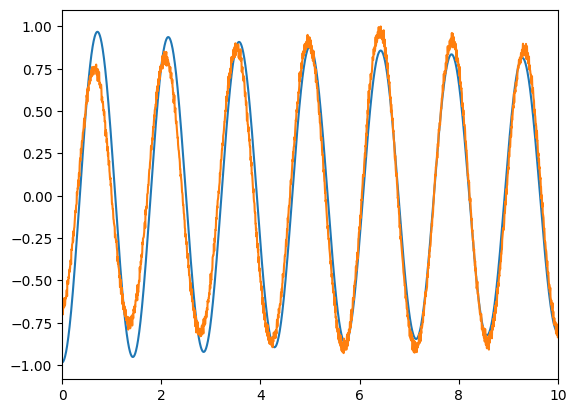

In [20]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

## Fit exponencial

d_1 = (tiempo_m1[-1] - tiempo_m1[0])/len(tiempo_m1) #Intervalo de tiempo por número de puntos
d_2 = (tiempo_2[-1] - tiempo_2[0])/len(tiempo_2)
w1_c1 = frecuencia_pico_2_celular_1
w1_c2 = frecuencia_pico_2_celular_2
T1 = (2*np.pi/(w1_c1))/(d_1) # Periodo en número de puntos
T2 = (2*np.pi/(w1_c2))/(d_2)
numero_batidos_c1 = int(len(tiempo_m1)/(T1/2))
numero_batidos_c2 = int(len(tiempo_2)/(T2/2))

aceleraciones_maximo_c1 = []
tiempos_maximo_c1= []
aceleraciones_maximo_c2 = []
tiempos_maximo_c2= []

for i in range(numero_batidos_c1):
    # Divido cada batido en un array
    tiempo_m1_aux = tiempo_m1[i*int(T1/2):(i+1)*int(T1/2)]
    aceleracion_y_1_aux = aceleracion_y_1[i*int(T1/2):(i+1)*int(T1/2)]

    # Hallo la posición del máximo de cada batido
    posicion_maximo_aceleracion = np.argmax(aceleracion_y_1_aux)
    #Formo los vectores tiempo y aceleración maximos
    aceleraciones_maximo_c1.append(aceleracion_y_1_aux[posicion_maximo_aceleracion])
    tiempos_maximo_c1.append(tiempo_m1_aux[posicion_maximo_aceleracion])

tiempos_maximo_c1[0] = 0

for i in range(numero_batidos_c2):
    # Divido cada batido en un array
    tiempo_m1_aux = tiempo_2[i*int(T2/2):(i+1)*int(T2/2)]
    aceleracion_y_1_aux = aceleracion_y_2[i*int(T2/2):(i+1)*int(T2/2)]

    # Hallo la posición del máximo de cada batido
    posicion_maximo_aceleracion = np.argmax(aceleracion_y_1_aux)
    #Formo los vectores tiempo y aceleración maximos
    aceleraciones_maximo_c2.append(aceleracion_y_1_aux[posicion_maximo_aceleracion])
    tiempos_maximo_c2.append(tiempo_m1_aux[posicion_maximo_aceleracion])

# Para verificar que todo está bien:
#plt.plot(tiempos_maximo_c2[:], aceleraciones_maximo_c2[:])
#plt.plot(tiempo_2[:], aceleracion_y_2[:])

## Definimos el ajuste exponencial
def modelo1(x, c, d, e, f):
    return c*np.exp(-d* x) + e*np.exp(-f*x)


## Realizamos el ajuste exponencial:
params_1, errr = curve_fit(modelo1, tiempos_maximo_c1[:], aceleraciones_maximo_c1[:])
params_2, errr_2 = curve_fit(modelo1, tiempos_maximo_c2[:], aceleraciones_maximo_c2[:])

## Creamos la curva exponencial:
x_continuo = np.linspace(min(tiempos_maximo_c2[:]), max(tiempos_maximo_c2[:]), 100)
y_fit_continuo_exponencial = modelo1(x_continuo, *params_2)

## Graficamos la regresión exponencial:
#plt.scatter(tiempos_maximo[:], aceleraciones_maximo[:], label='Datos', color='blue')
#plt.plot(x_continuo, y_fit_continuo_exponencial, label='Ajuste exponencial', color='orange')
#plt.xlabel('tiempo')
#plt.ylabel('a_max_y')
#plt.legend()
#plt.show()

#Valores hallados:
c_1 = params_1[0]
d_1 = params_1[1]
e_1 = params_1[2]
f_1 = params_1[3]

c_2 = params_2[0]
d_2 = params_2[1]
e_2 = params_2[2]
f_2 = params_2[3]

wa_c1 = frecuencia_pico_2_celular_1
ws_c1 = frecuencia_pico_2_celular_1

wa_c2 = frecuencia_pico_2_celular_2
ws_c2 = frecuencia_pico_2_celular_2

graf_aceleracion_c1 = (ws_c1*ws_c1*np.cos(ws_c1*tiempo_m1) )*(c_1*np.exp(-d_1* tiempo_m1) + e_1*np.exp(-f_1*tiempo_m1))/(ws_c1**2)
graf_aceleracion_c2 = -(ws_c2*ws_c2*np.cos(ws_c2*tiempo_2) )*(c_2*np.exp(-d_2* tiempo_2) + e_2*np.exp(-f_2*tiempo_2))/(ws_c2**2)

## Para verificar la 
plt.plot(tiempo_2[:],graf_aceleracion_c2[:])
plt.plot(tiempo_2[:],aceleracion_y_2[:])
plt.xlim(0, 10)

## Graficar

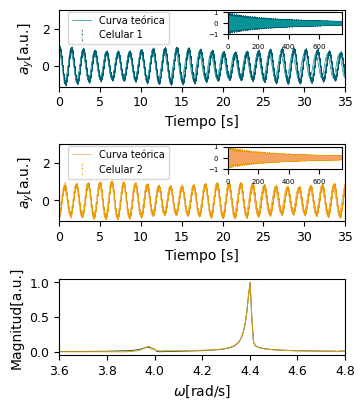

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(3.75, 4.2))

error_y = np.full(len(tiempo_m1), 0.04)

ax1 = plt.subplot(3, 1, 1)
#plt.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt='.', color='#005F73', capsize=0.3, label='Celular 1', markersize=0.1, elinewidth=0.5)
plt.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt=',', color='#005F73', capsize=0.3, label='Celular 1', elinewidth=0.2)
#plt.plot(tiempo_m1, aceleracion_y_1, color='#005F73', label='Celular 1', linewidth=0.5)
plt.plot(tiempo_m1[:],graf_aceleracion_c1[:], label='Curva teórica', linewidth=0.5, color='#0A9396')
plt.legend(loc='lower right', bbox_to_anchor=(0.4, 0.49), fontsize=7)
plt.xlabel('Tiempo [s]', fontsize=10)
plt.ylabel(r"$a_y$[a.u.]", fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(0, 35)
plt.ylim(-1.1, 3.)
# Agregar el inset en el primer gráfico
inset_ax = ax1.inset_axes([0.59, 0.68, 0.40, 0.29])  # [x0, y0, ancho, alto] en fracciones del gráfico principal
#inset_ax.errorbar(tiempo_m1, aceleracion_y_1, yerr=error_y, fmt=',', color='#005F73', capsize=0.1, elinewidth=0.2)
inset_ax.plot(tiempo_m1, aceleracion_y_1, color='#005F73', linewidth=0.3)
inset_ax.plot(tiempo_m1[:],graf_aceleracion_c1[:], linewidth=0.1, color='#0A9396')
inset_ax.tick_params(labelsize=5)
inset_ax.set_xlim(0, 750)  # Ajusta los límites para hacer zoom
inset_ax.set_ylim(-1, 1)

error_y = np.full(len(tiempo_2), 0.04)

ax2 = plt.subplot(3, 1, 2)
plt.errorbar(tiempo_2, aceleracion_y_2, yerr=error_y, fmt=',', color='#EE9B00', capsize=0.3, label='Celular 2', elinewidth=0.2)
#plt.plot(tiempo_2, aceleracion_y_2, color='#EE9B00', label='Celular 2', linewidth=0.5)
plt.plot(tiempo_2[:],graf_aceleracion_c2[:], label='Curva teórica', linewidth=0.5, color='#F4A261')
plt.legend(loc='lower right', bbox_to_anchor=(0.4, 0.49), fontsize=7)
plt.xlabel('Tiempo [s]', fontsize=10)
plt.ylabel(r"$a_y$[a.u.]", fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(0, 35)
plt.ylim(-1.1, 3.)
# Agregar el inset en elsegundo gráfico
inset_ax = ax2.inset_axes([0.59, 0.68, 0.40, 0.29])  # [x0, y0, ancho, alto] en fracciones del gráfico principal
#inset_ax.errorbar(tiempo_2, aceleracion_y_2, yerr=error_y, fmt=',', color='#EE9B00', capsize=1)
inset_ax.plot(tiempo_2, aceleracion_y_2, color='#EE9B00', linewidth=0.3)
inset_ax.plot(tiempo_2[:],graf_aceleracion_c2[:], linewidth=0.1, color='#F4A261')
inset_ax.tick_params(labelsize=5)
inset_ax.set_xlim(0, 750)  # Ajusta los límites para hacer zoom
inset_ax.set_ylim(-1, 1)

ax3 = plt.subplot(3, 1, 3)

frecuencia_maximo_grafica_1 = len(frecuencias_1_m1)//2 # Hasta 800 para primer pico
frecuencia_maximo_grafica_2 = len(frecuencias_2)//2
auxiliar_normalizar = np.abs(fft_resultados_1)[:len(fft_resultados_1)//2]/np.max(np.abs(fft_resultados_1)[:len(fft_resultados_1)//2])
plt.plot(frecuencias_1_m1[:len(frecuencias_1_m1)//2]*(2* np.pi), auxiliar_normalizar, color='#005F73', linewidth=0.7)  # Solo la mitad positiva
auxiliar_normalizar = np.abs(fft_resultados_2)[:len(fft_resultados_2)//2]/np.max(np.abs(fft_resultados_2)[:len(fft_resultados_2)//2])
plt.plot(frecuencias_2[:len(fft_resultados_2)//2]*(2* np.pi), auxiliar_normalizar, color='#EE9B00', linewidth=0.7)  
#plt.title('Transformada Rápida de Fourier')
plt.xlabel(r"$\omega$[rad/s]", fontsize=10)
plt.ylabel('Magnitud[a.u.]', fontsize=10)
plt.tick_params(labelsize=9)
plt.xlim(3.6,4.8)

plt.tight_layout()


plt.savefig("modo_antisimetrico.png", dpi=300, bbox_inches='tight')

plt.show()

#plt.xlim(0, 750)
#inset_ax.set_xlim(0, 48)


In [22]:
import numpy as np
auxiliar_normalizar = np.abs(fft_resultados_1)[:len(fft_resultados_1)//2]/np.max(np.abs(fft_resultados_1)[:len(fft_resultados_1)//2])
data_exportar_transformada_Fourier_1 = np.column_stack((frecuencias_1_m1[:len(fft_resultados_1)//2]*(2* np.pi), auxiliar_normalizar))
np.savetxt("MA_FFT_C1.csv", data_exportar_transformada_Fourier_1, delimiter=",", header="Frecuencia, Magnitud", comments="")

auxiliar_normalizar = np.abs(fft_resultados_2)[:len(fft_resultados_2)//2]/np.max(np.abs(fft_resultados_2)[:len(fft_resultados_2)//2])
data_exportar_transformada_Fourier_2 = np.column_stack((frecuencias_2[:len(fft_resultados_2)//2]*(2* np.pi), auxiliar_normalizar))
np.savetxt("MA_FFT_C2.csv", data_exportar_transformada_Fourier_2, delimiter=",", header="Frecuencia, Magnitud", comments="")
